# Biomass HTT/HTL Database – Load & Inspect

This notebook demonstrates how to load and explore the curated biomass hydrothermal treatment (HTT/HTL/HTC) dataset.

### Contents (indicative)
**Data loading** – Import master dataset and examine structure
**Basic statistics** – Process types, temperature ranges, completeness
**Yield analysis** – Bio-oil/char/gas yield distributions
**Van Krevelen diagrams** – Feedstock composition visualization
**Van Krevelen clustering** – K-means clustering in VK space
**Feedstock family distribution** – Circular plot of dominant families
**QA envelopes** – Energy/carbon balance and yield closure checks
**Yield closure comparison** – Compare with external datasets (optional)
**Filtering examples** – Extract subsets (e.g., HTL ≥300°C)
**Feature distributions** – Histograms of key numeric variables

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../modules')

df = pd.read_csv('../master_dataset.csv')
print(f"Loaded {len(df):,} experiments × {len(df.columns)} columns")

Loaded 3,543 experiments × 103 columns


### . Basic data structure

In [9]:
df.head(3)

,paper_title,DOI,year,Provenance,Ref,Feedstock,Family_std,C_feed_wt_pct,H_feed_wt_pct,O_feed_wt_pct,...,Lignin_imputed,cellulose_method,cellulose_imputed,hemicellulose_method,hemicellulose_imputed,Ash_method,Ash_imputed,LRI_imputed_source,LCH_total_imputed_source,Lignin_share_imputed_source
0,Liquid Fuel Production from Woody Biomass by D...,https://doi.org/10.1627/jpi1958.36.73,1993,Table 8 — Heavy oil properties (2-PrOH series),"Ogi & Yokoyama, Sekiyu Gakkaishi 36(2):73–84 (...",Japanese oak (Konara),Woody Biomass / Hardwood,46.65,5.83,47.31,...,False,Ogi1993_C+H_split_family_median,True,Ogi1993_C+H_split_family_median,True,NaN,False,formula,formula,formula
1,Hydrothermal processing of duckweed: Effect of...,https://doi.org/10.1016/j.biortech.2012.08.106,2013,"Fig. 2a — effect of temperature (60 min, 2.5 g)",Duan_2013_BioresourceTech,Duckweed (Lemna sp.),Aquatic Biomass,30.00,4.30,20.10,...,False,NaN,False,NaN,False,NaN,False,formula,formula,formula
2,Hydrothermal processing of duckweed: Effect of...,https://doi.org/10.1016/j.biortech.2012.08.106,2013,"Table 1 — elemental composition of bio-oil, te...",Duan_2013_BioresourceTech,Duckweed (Lemna sp.),Aquatic Biomass,30.00,4.30,20.10,...,False,NaN,False,NaN,False,NaN,False,formula,formula,formula


In [10]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3543 entries, 0 to 3542
Columns: 103 entries, paper_title to Lignin_share_imputed_source
dtypes: bool(5), float64(61), int64(1), object(36)
memory usage: 2.7+ MB


### Process types and temperature ranges

In [11]:
print("Process types:")
print(df['process_type'].value_counts())
print(f"\nTemperature range: {df['T_reaction_C'].min():.0f}–{df['T_reaction_C'].max():.0f} °C")

Process types:
process_type
Hydrothermal    3543
Name: count, dtype: int64

Temperature range: 20–603 °C


### Feedstock families

In [12]:
print(f"{df['Family_std'].nunique()} feedstock families:")
print(df['Family_std'].value_counts().head(10))

14 feedstock families:
Family_std
Agricultural Residues              1325
Woody Biomass / Softwood            521
Woody Biomass / Hardwood            498
Mixed Biomass                       290
Lignin-rich Streams (Technical)     290
Unknown                             149
Animal Manure                       124
Waste Biomass / Sludge               92
Woody Biomass / Unspecified          71
Herbaceous Biomass                   60
Name: count, dtype: int64


### Data completeness

In [13]:
completeness = (df.notna().sum() / len(df) * 100).sort_values(ascending=False)

print("Top 15 most complete columns:")
for col, pct in completeness.head(15).items():
    print(f"{col:30s} {pct:5.1f}%")

Top 15 most complete columns:
paper_title                    100.0%
year                           100.0%
Family_std                     100.0%
process_type                   100.0%
LCH_closure_flag               100.0%
sum_CHONS_wt_pct               100.0%
C_feed_wt_pct                  100.0%
sum_CHONSAsh_wt_pct            100.0%
HHV_feed_MJ_per_kg             100.0%
O_C_feed_molar                 100.0%
H_C_feed_molar                 100.0%
process_subtype                100.0%
HC_method                      100.0%
Ash_imputed                    100.0%
Lignin_imputed                 100.0%


### Distribution by date

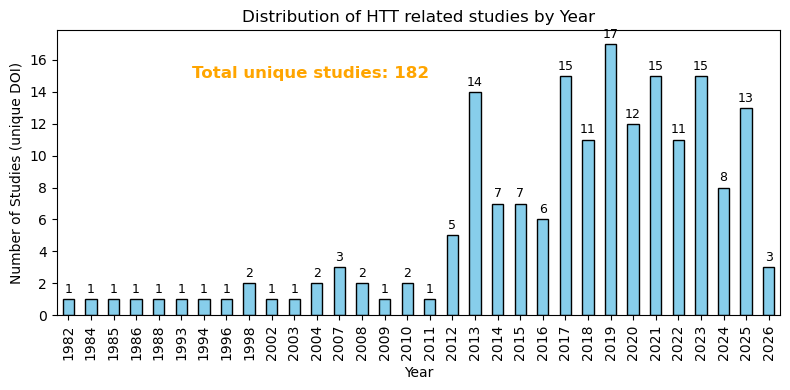

In [14]:
plt.figure(figsize=(8, 4))
unique_studies = df.drop_duplicates(subset='DOI')
year_counts = unique_studies['year'].dropna().astype(int).value_counts().sort_index()
ax = year_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel('Year')
plt.ylabel('Number of Studies (unique DOI)')
plt.title('Distribution of HTT related studies by Year')
plt.tight_layout()

for i, count in enumerate(year_counts):
    ax.text(i, count + 0.2, str(count), ha='center', va='bottom', fontsize=9)

total_studies = len(unique_studies)
ax.text(
    0.35, 0.85, 
    f'Total unique studies: {total_studies}', 
    ha='center', va='center', 
    fontsize=12, fontweight='bold', color="orange",
    transform=ax.transAxes
)

plt.show()

### Elemental and polymer closure

In [15]:
df.columns.tolist()

['paper_title',
 'DOI',
 'year',
 'Provenance',
 'Ref',
 'Feedstock',
 'Family_std',
 'C_feed_wt_pct',
 'H_feed_wt_pct',
 'O_feed_wt_pct',
 'N_feed_wt_pct',
 'S_feed_wt_pct',
 'Ash_feed_wt_pct',
 'Lignin_feed_wt_pct',
 'Cellulose_feed_wt_pct',
 'Hemicellulose_feed_wt_pct',
 'Extractives_feed_wt_pct',
 'LCH_total_wt_pct',
 'Lignin_share_pct',
 'Holo_share_pct',
 'Lignin_from_LCH_wt_pct',
 'Cellulose_from_LCH_wt_pct',
 'Hemicellulose_from_LCH_wt_pct',
 'Moisture_min_wt_pct_ar',
 'Moisture_max_wt_pct_ar',
 'O_C_feed_molar',
 'H_C_feed_molar',
 'HHV_feed_MJ_per_kg',
 'LRI',
 'LRI_imputed',
 'sum_LCH_wt_pct',
 'sum_CHONSAsh_wt_pct',
 'sum_CHONS_wt_pct',
 'LCH_closure_flag',
 'process_type',
 'process_subtype',
 'reactor',
 'atmosphere',
 'solvent_or_medium',
 'T_reaction_C',
 't_residence_min',
 't_ramp_min',
 'IC_feed_wt_pct_slurry',
 'pressure_reaction_MPa',
 'heating_rate_C_per_min',
 'stirring_rpm',
 'water_biomass_ratio_kg_kg',
 'catalyst',
 'cat_biomass_ratio_kg_kg',
 'yield_basis',
 

=== Polymer closure (Lignin + Cellulose + Hemicellulose) ===
count    3402.000000
mean       80.989072
std        23.042893
min         0.000000
25%        76.800611
50%        88.373584
75%        95.000000
max       125.000000
Name: sum_LCH, dtype: float64

Flag counts:
LCH_flag
OK         3454
LCH>105      70
LCH>110      19
Name: count, dtype: int64

Top 20 rows with highest sum_LCH:
                                          DOI                      Feedstock  Lignin_feed_wt_pct  Cellulose_feed_wt_pct  Hemicellulose_feed_wt_pct    sum_LCH LCH_flag
https://doi.org/10.1016/S0961-9534(98)00006-3                      Rice husk               42.58              44.140000                  38.280000 125.000000  LCH>110
https://doi.org/10.1016/S0961-9534(98)00006-3                 Oil-palm shell               48.91              52.130000                  23.570000 124.610000  LCH>110
       https://doi.org/10.1627/jpi1958.28.239 Japanese oak (Quercus serrata)               21.27            

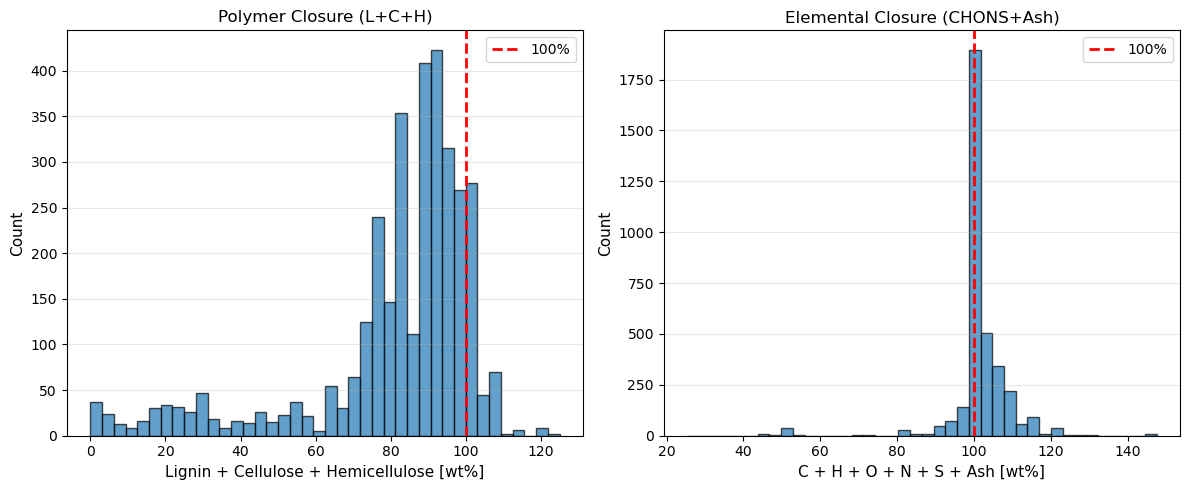

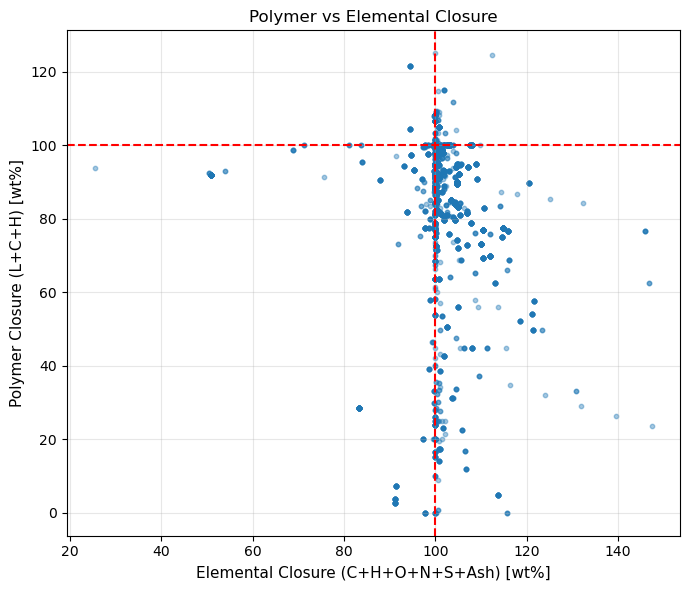

In [16]:
import importlib
import closure_validator
importlib.reload(closure_validator)

from closure_validator import validate_closures

df = validate_closures(df, upper_tol_LCH_soft=105.0, upper_tol_LCH_hard=110.0, 
                       lower_tol_LCH=-1e-6, show_plots=True, show_stats=True)

### Temperature distribution

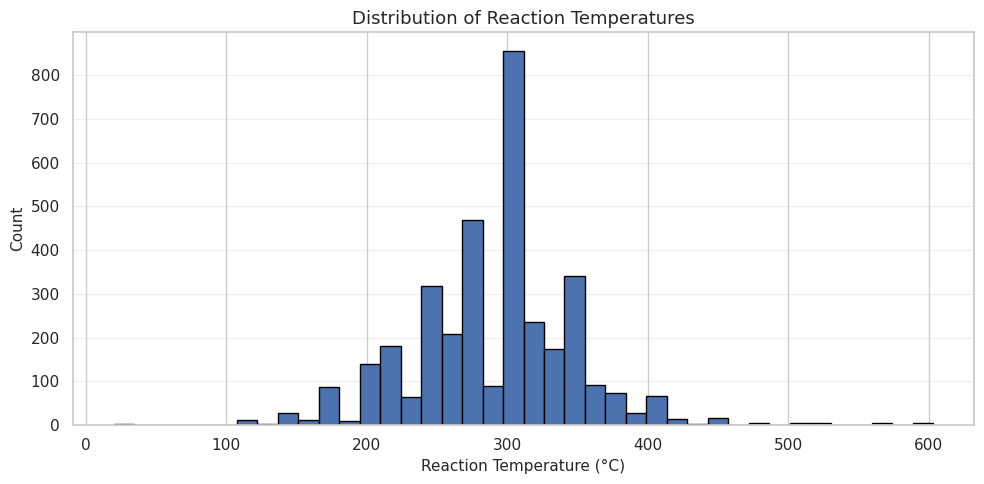

In [28]:
plt.figure(figsize=(10, 5))
df['T_reaction_C'].hist(bins=40, edgecolor='black')
plt.xlabel('Reaction Temperature (°C)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.title('Distribution of Reaction Temperatures', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Bio-oil yield distribution

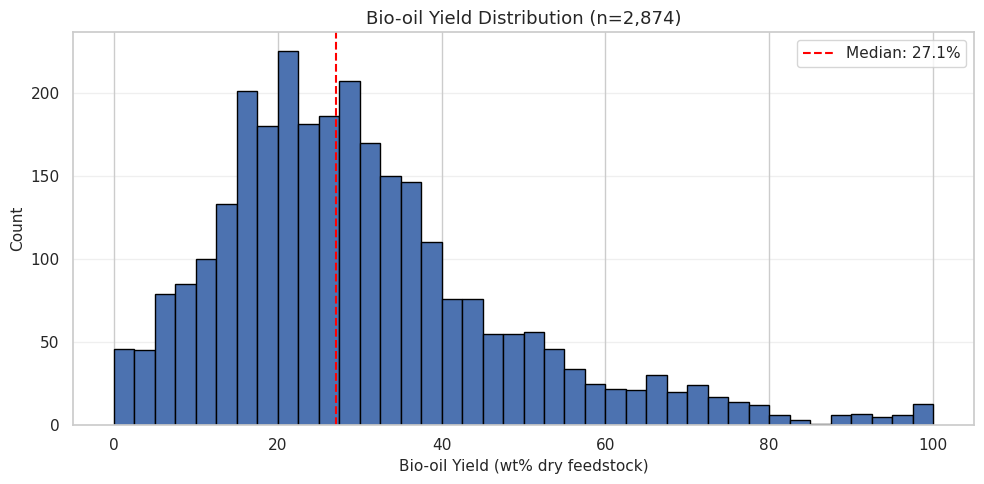

Bio-oil yield stats: mean=30.1%, median=27.1%, std=17.8%


In [29]:
biooil_data = df['Yield_biooil_wt_pct'].dropna()

plt.figure(figsize=(10, 5))
biooil_data.hist(bins=40, edgecolor='black')
plt.xlabel('Bio-oil Yield (wt% dry feedstock)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.title(f'Bio-oil Yield Distribution (n={len(biooil_data):,})', fontsize=13)
plt.axvline(biooil_data.median(), color='red', linestyle='--', label=f'Median: {biooil_data.median():.1f}%')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bio-oil yield stats: mean={biooil_data.mean():.1f}%, median={biooil_data.median():.1f}%, std={biooil_data.std():.1f}%")

### Van Krevelen diagram (feedstock)

=== MARKER LEGEND FOR FAMILIES ===
o  = Woody Biomass / Hardwood
s  = Woody Biomass / Softwood
D  = Woody Biomass / Unspecified
^  = Herbaceous Biomass
v  = Agricultural Residues
P  = Aquatic Biomass
*  = Model Compound
p  = Mixed Biomass
h  = Waste Biomass / Sludge
<  = Animal Manure
>  = Waste Wood / Construction
+  = Unknown


/home/Elfetni/Biomass_HTT_DB/DB_release/notebooks/../modules/van_krevelen_plotter.py:94: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


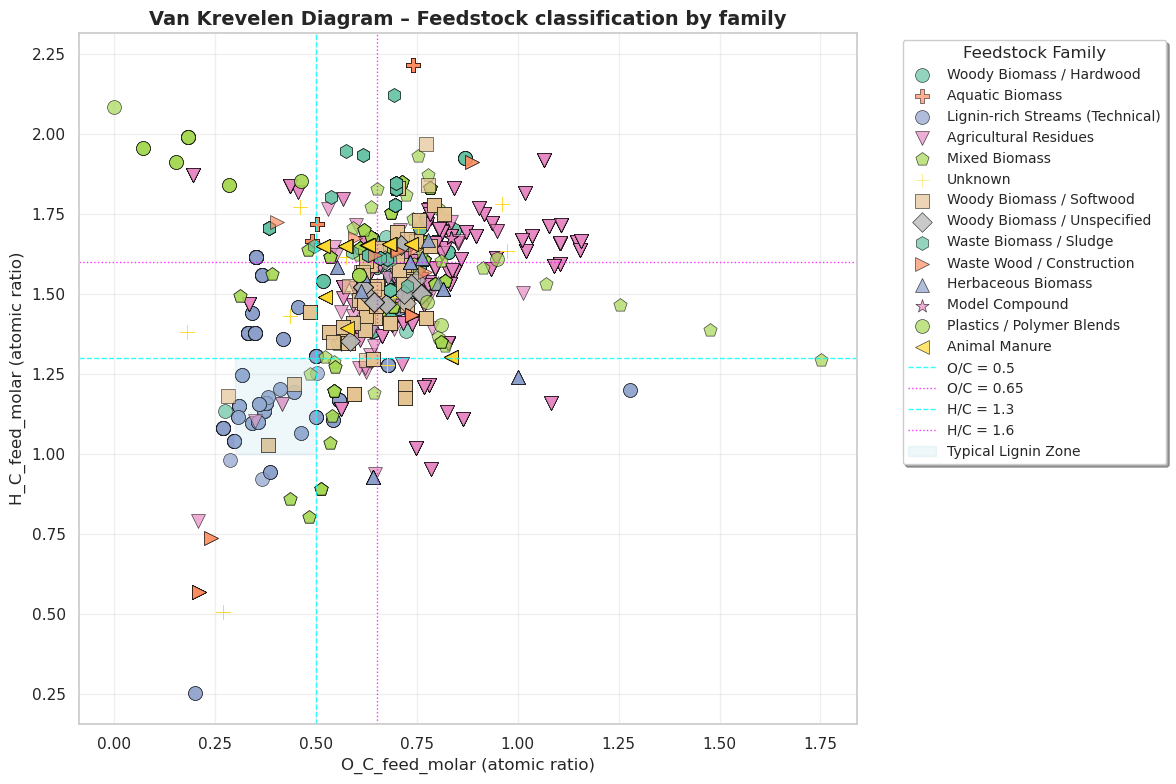

In [30]:
from van_krevelen_plotter import plot_van_krevelen_diagram

fig = plot_van_krevelen_diagram(
    df=df, 
    family_col='Family_std', 
    oc_col='O_C_feed_molar', 
    hc_col='H_C_feed_molar',
    figsize=(12, 8), 
    show_reference_lines=True, 
    show_lignin_zone=True, 
    show_marker_legend=True
)

Van Krevelen clustering analysis on 3,543 samples
Testing k = 2 to 10 clusters

k= 2: silhouette score = 0.4629
k= 3: silhouette score = 0.3626
k= 4: silhouette score = 0.3997
k= 3: silhouette score = 0.3626
k= 4: silhouette score = 0.3997
k= 5: silhouette score = 0.3915
k= 6: silhouette score = 0.4073
k= 5: silhouette score = 0.3915
k= 6: silhouette score = 0.4073
k= 7: silhouette score = 0.3963
k= 8: silhouette score = 0.4208
k= 7: silhouette score = 0.3963
k= 8: silhouette score = 0.4208
k= 9: silhouette score = 0.4207
k=10: silhouette score = 0.4442

✓ Optimal k = 2 (silhouette = 0.4629)
k= 9: silhouette score = 0.4207
k=10: silhouette score = 0.4442

✓ Optimal k = 2 (silhouette = 0.4629)


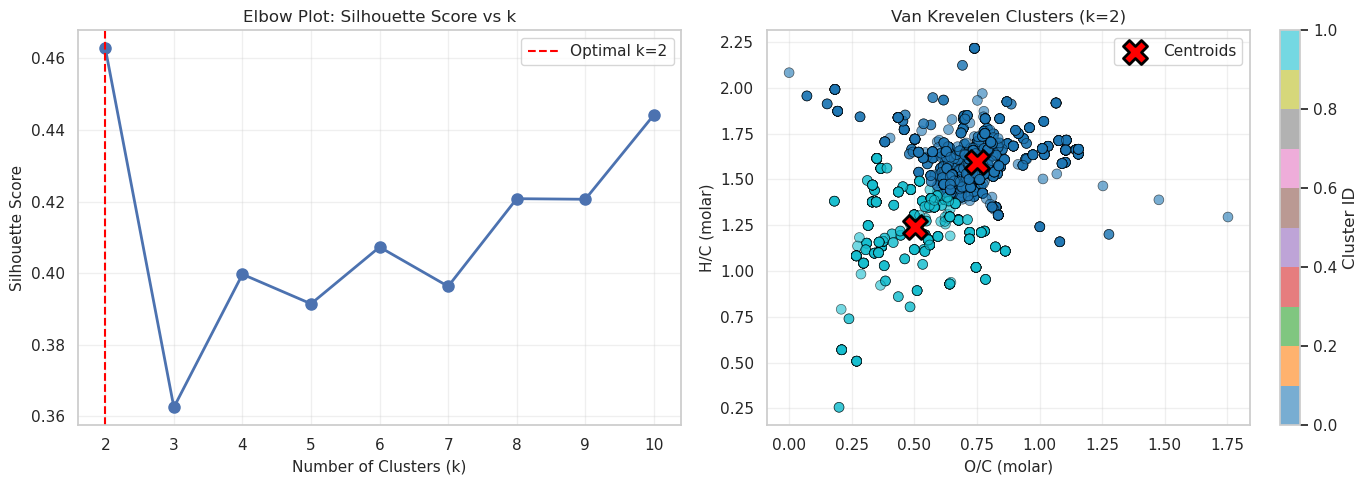


CLUSTER CENTROIDS (Van Krevelen space)
         O_C_feed_molar  H_C_feed_molar
Cluster                                
0              0.751871        1.595017
1              0.504305        1.237926

CLUSTER SIZE DISTRIBUTION
Cluster 0:  2867 samples ( 80.9%)
Cluster 1:   676 samples ( 19.1%)

DOMINANT FAMILY PER CLUSTER
Cluster 0: Agricultural Residues (1202/2867 = 41.9%)
Cluster 1: Lignin-rich Streams (Technical) (281/676 = 41.6%)


In [31]:
from van_krevelen_clustering import complete_van_krevelen_clustering_analysis

df, clustering_results = complete_van_krevelen_clustering_analysis(
    df=df, 
    oc_col="O_C_feed_molar", 
    hc_col="H_C_feed_molar", 
    family_col="Family_std",
    k_min=2, 
    k_max=10, 
    random_state=42, 
    show_plots=True, 
    show_tables=True, 
    verbose=True
)

k_best = clustering_results['k_best']
centroids = clustering_results['centroids']

### Feedstock family distribution

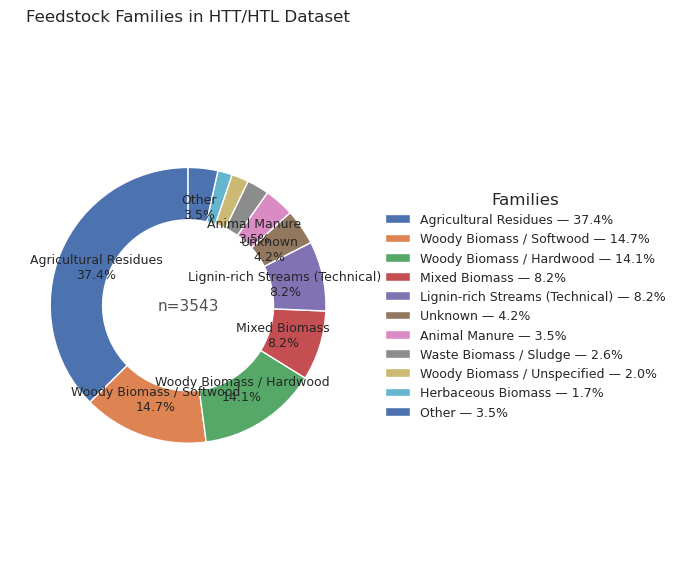


Top families:
                         Family_std  percent
0             Agricultural Residues    37.40
1          Woody Biomass / Softwood    14.71
2          Woody Biomass / Hardwood    14.06
3                     Mixed Biomass     8.19
4   Lignin-rich Streams (Technical)     8.19
5                           Unknown     4.21
6                     Animal Manure     3.50
7            Waste Biomass / Sludge     2.60
8       Woody Biomass / Unspecified     2.00
9                Herbaceous Biomass     1.69
10                            Other     3.47


In [32]:
from family_normalizer import plot_family_circular_distribution

res = plot_family_circular_distribution(
    df,
    family_col='Family_std',
    min_share_to_label=0.03,
    min_share_to_keep=0.015,
    top_n=10,
    title='Feedstock Families in HTT/HTL Dataset',
    savepath=None
)

if res:
    print("\nTop families:")
    print(res['table'])

### QA envelopes: yields and energy/carbon balances

In [15]:
df["process_subtype"].unique()

array(['HTL_solvothermal', 'HTC', 'HTL', 'APR'], dtype=object)

In [16]:
df.columns

Index(['paper_title', 'DOI', 'year', 'Provenance', 'Ref', 'Feedstock',
       'Family_std', 'C_feed_wt_pct', 'H_feed_wt_pct', 'O_feed_wt_pct',
       ...
       'hemicellulose_imputed', 'Ash_method', 'Ash_imputed', 'LRI_imputed',
       'LRI_imputed_source', 'LCH_total_imputed', 'LCH_total_imputed_source',
       'Lignin_share_imputed', 'Lignin_share_imputed_source', 'VK_cluster'],
      dtype='object', length=106)

E_H > 25.0 MJ/kg: 15 rows
E_B > 25.0 MJ/kg: 29 rows
B_Y outside [0,100]: 0 rows
C_Y outside [0,100]: 0 rows
C_B > 0.60 (fraction): 34 rows
C_H > 0.65 (fraction): 4 rows
HHV_input < 12 MJ/kg: 312 rows
H/C outside ~[0.8,1.9]: 87 rows
O/C outside ~[0.35,0.95]: 457 rows

-- E_H > 25.0 (showing 5 of 15) --
                         Feedstock          proc      T      t  B_Y    C_Y  \
192  Industrial kraft lignin (IKL)  hydrothermal  200.0  360.0  NaN  94.86   
346  Industrial kraft lignin (IKL)  hydrothermal  220.0  360.0  NaN  92.93   
559  Industrial kraft lignin (IKL)  hydrothermal  240.0  360.0  NaN  90.79   
560  Industrial kraft lignin (IKL)  hydrothermal  240.0  180.0  NaN  93.01   
615        CGT+LDPE (CGT:LDPE=1:2)  hydrothermal  240.0  105.0  7.6  87.80   

     A_Y  G_Y  HHV_biooil  HHV_biochar     E_B        E_H       C_B       C_H  \
192  NaN  NaN         NaN    27.449292     NaN  26.038398       NaN  0.623230   
346  NaN  NaN         NaN    27.345811     NaN  25.412462       Na

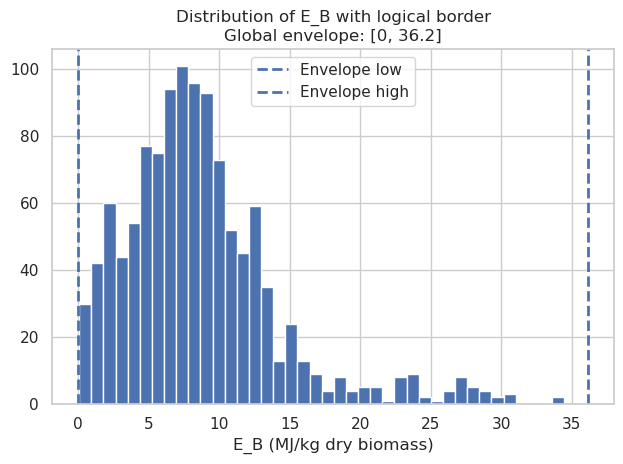

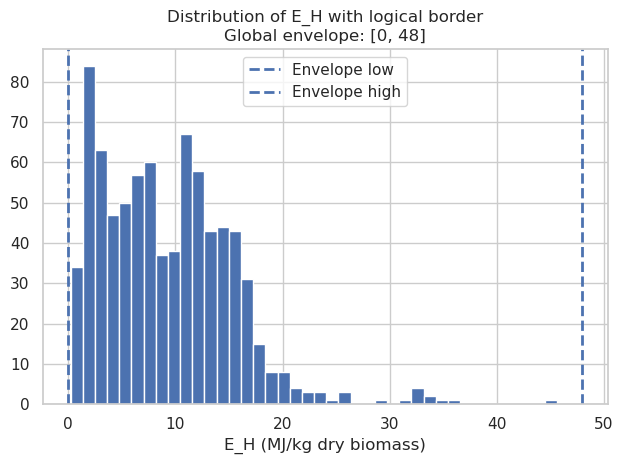

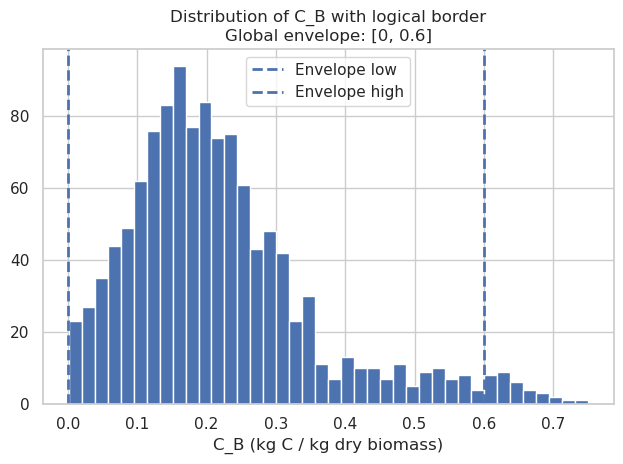

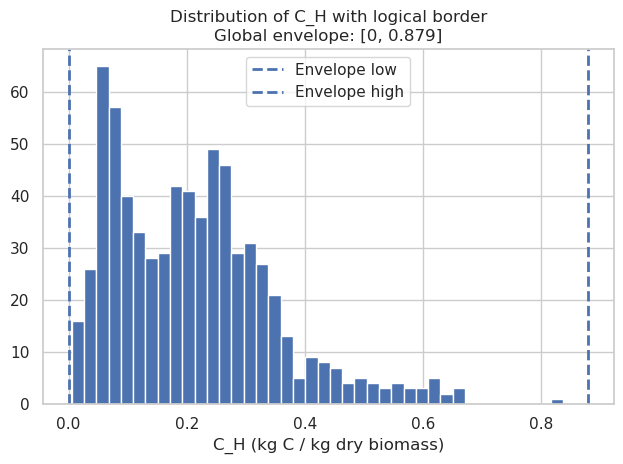

Mass-balance check (B_Y+C_Y+A_Y+G_Y ≈ 100): 126 violations out of 843 rows


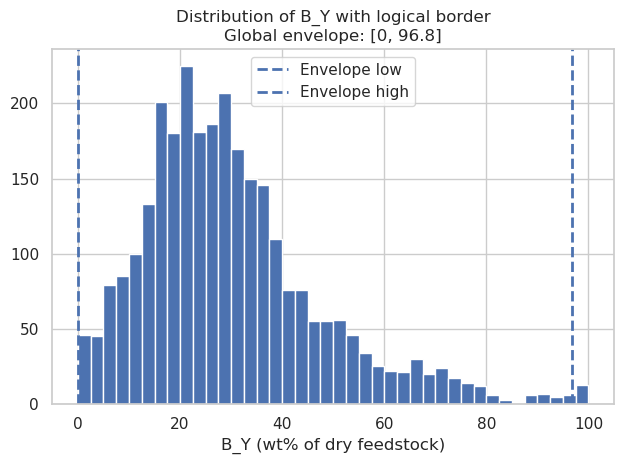

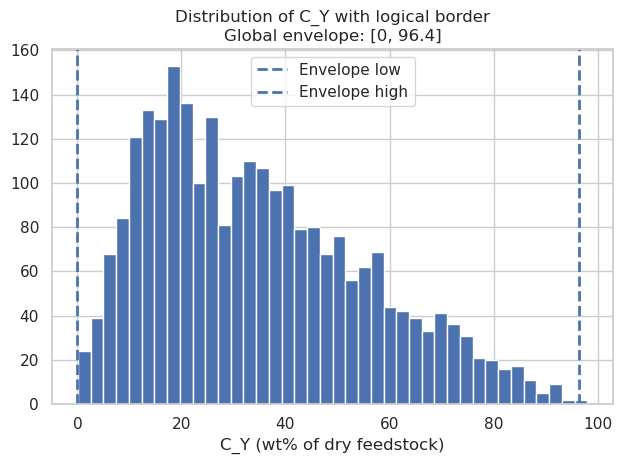

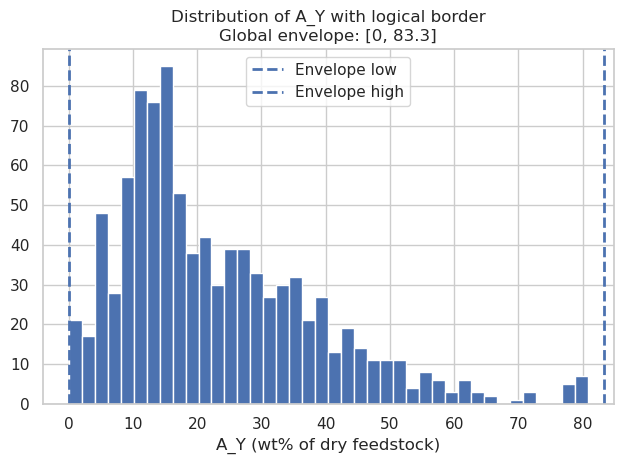

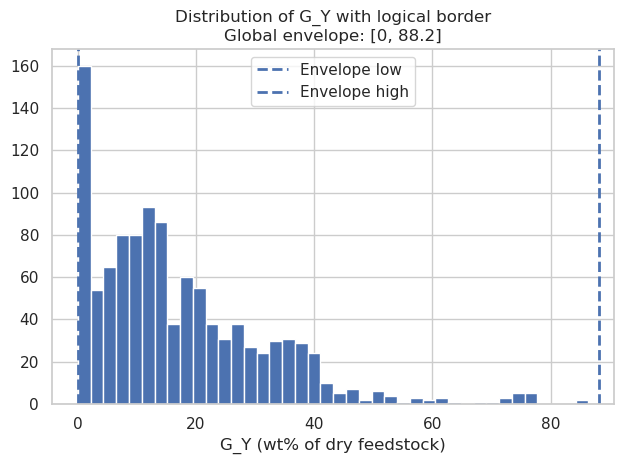

In [17]:
import qa_envelopes

from qa_envelopes import build_df_for_qa



df_derived = build_df_for_qa(df)

qa_envelopes.run_basic_qc(df_derived)

qa_envelopes.plot_energy_carbon_envelopes(df_derived)

qa_envelopes.plot_yield_envelopes(df_derived)

### Feature distributions with logical borders by process subtype

Features: 14 | Total rows: 3543
Processes: ['APR', 'HTC', 'HTL', 'HTL_solvothermal']
Serial plots: 14 features
Processes: ['APR', 'HTC', 'HTL', 'HTL_solvothermal']


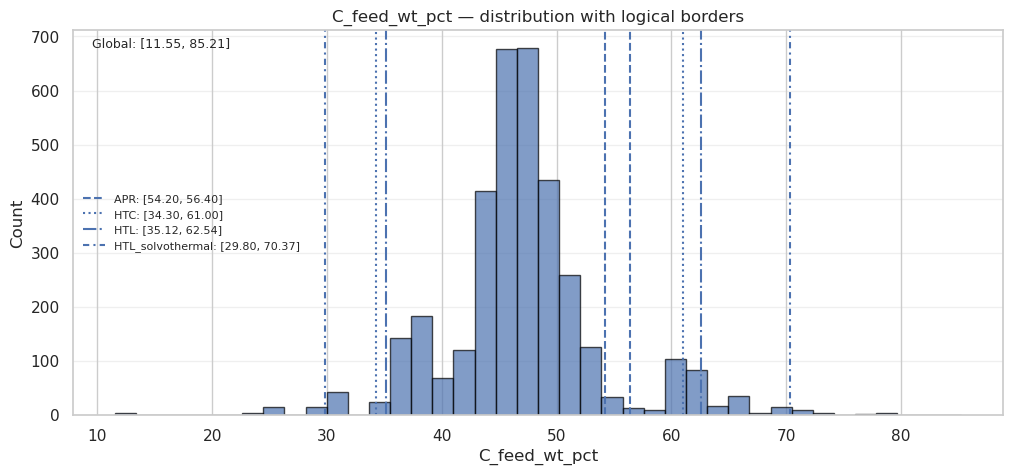

C_feed_wt_pct: n=3543 range=[11.55, 85.21]


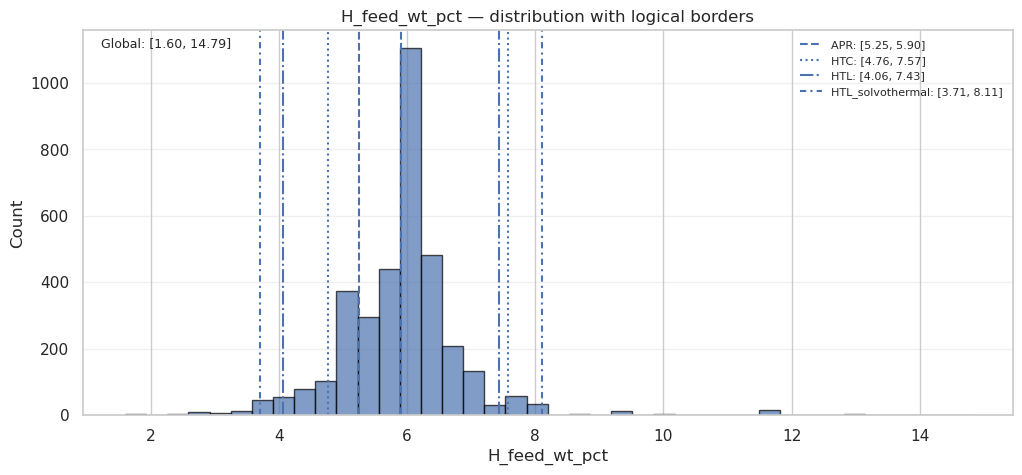

H_feed_wt_pct: n=3495 range=[1.6, 14.79]


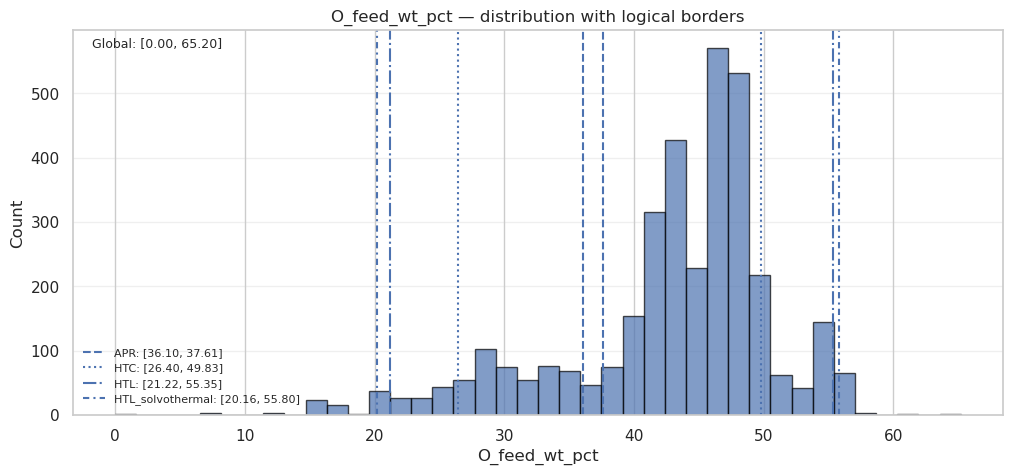

O_feed_wt_pct: n=3493 range=[0, 65.2]


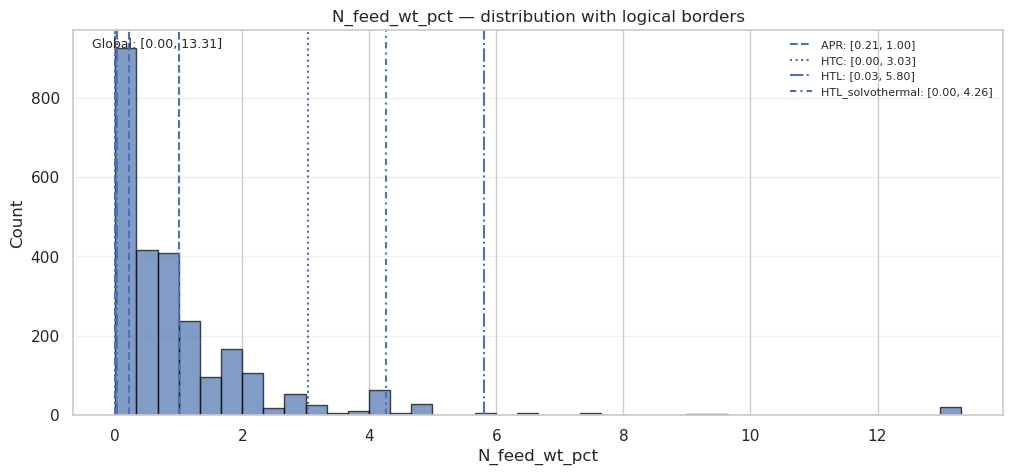

N_feed_wt_pct: n=2608 range=[0, 13.31]


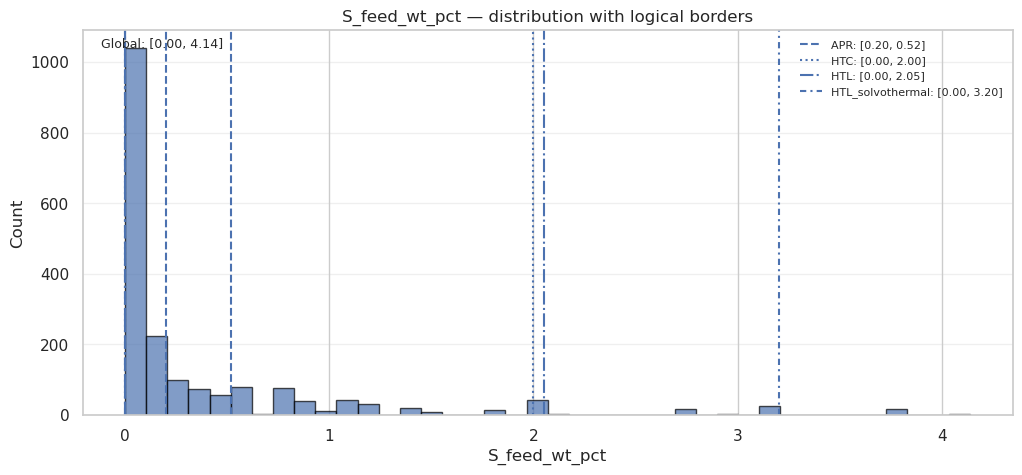

S_feed_wt_pct: n=1936 range=[0, 4.14]


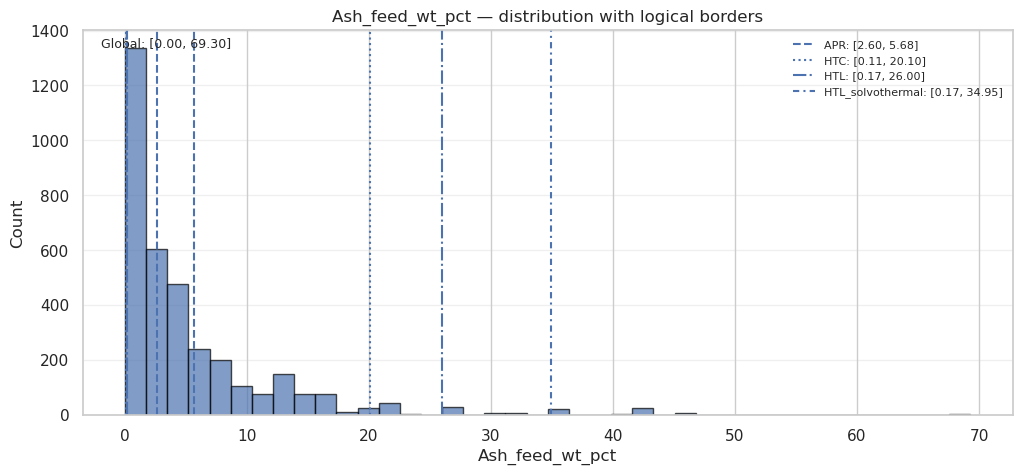

Ash_feed_wt_pct: n=3529 range=[0, 69.3]


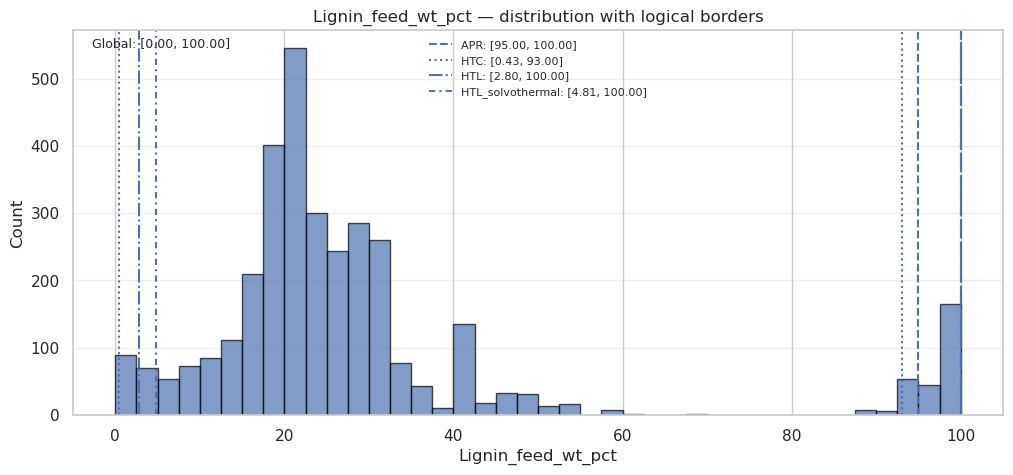

Lignin_feed_wt_pct: n=3396 range=[0, 100]


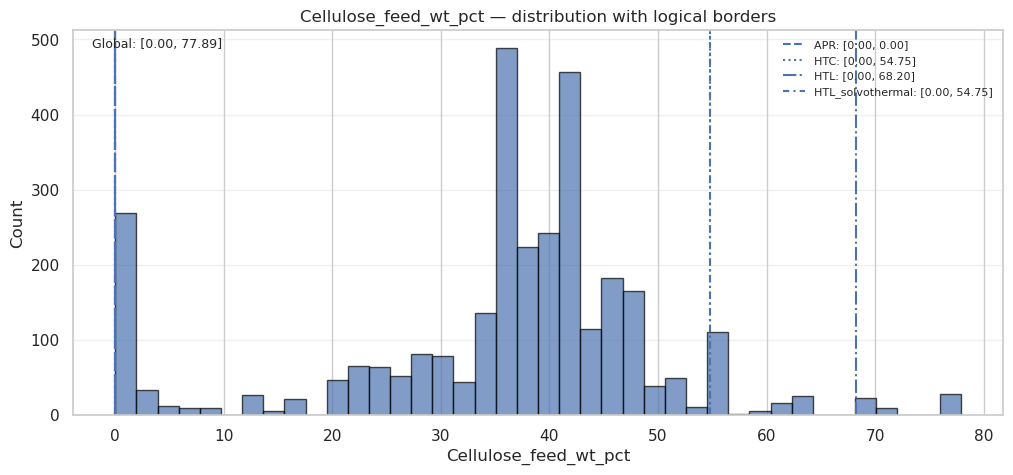

Cellulose_feed_wt_pct: n=3144 range=[0, 77.89]


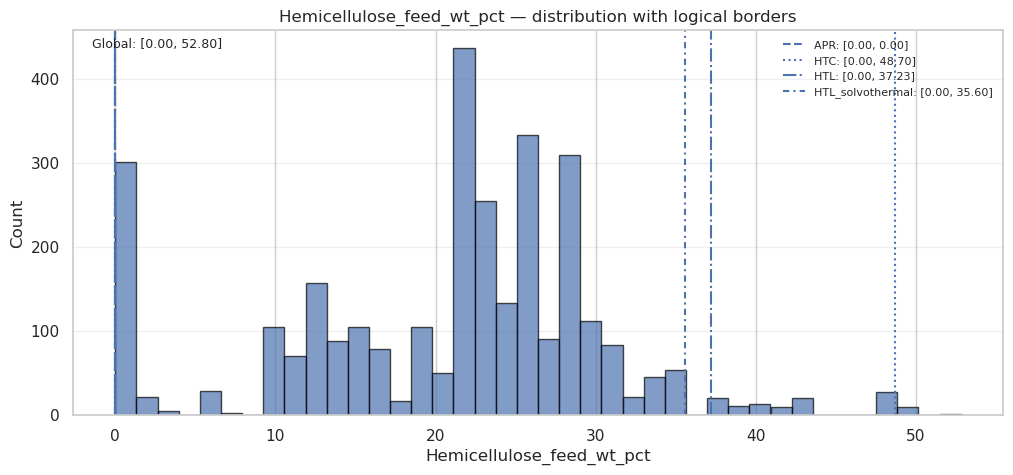

Hemicellulose_feed_wt_pct: n=3114 range=[0, 52.8]


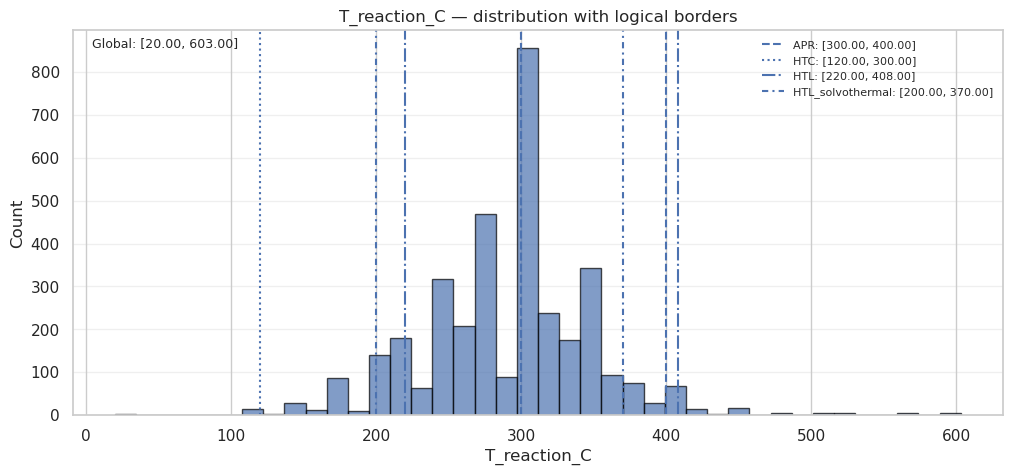

T_reaction_C: n=3542 range=[20, 603]


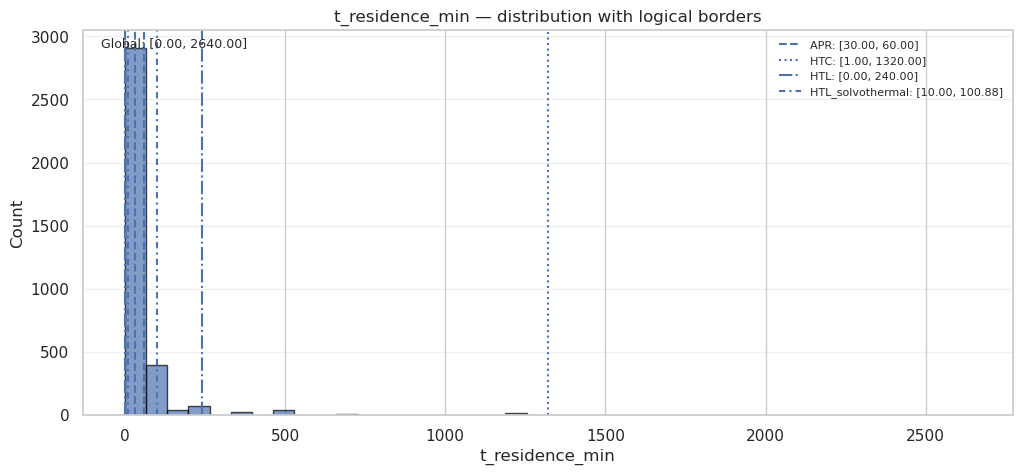

t_residence_min: n=3530 range=[0, 2640]


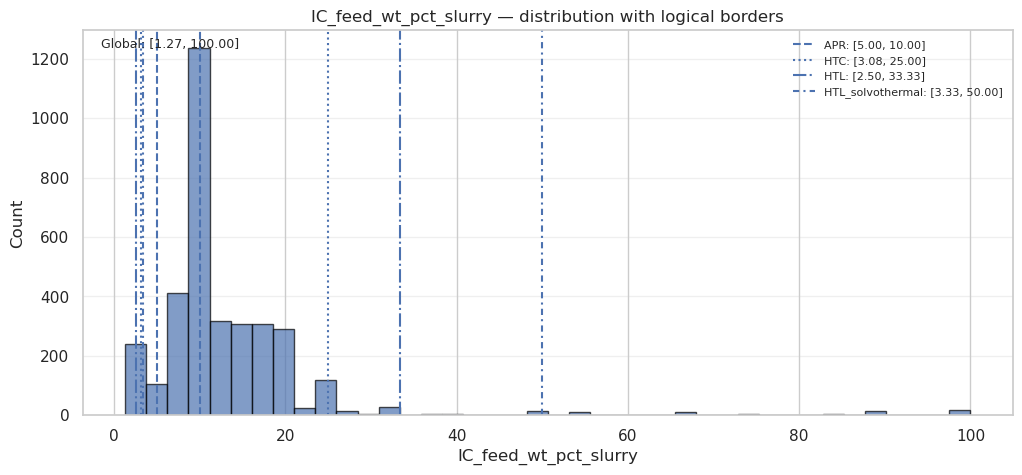

IC_feed_wt_pct_slurry: n=3472 range=[1.266, 100]


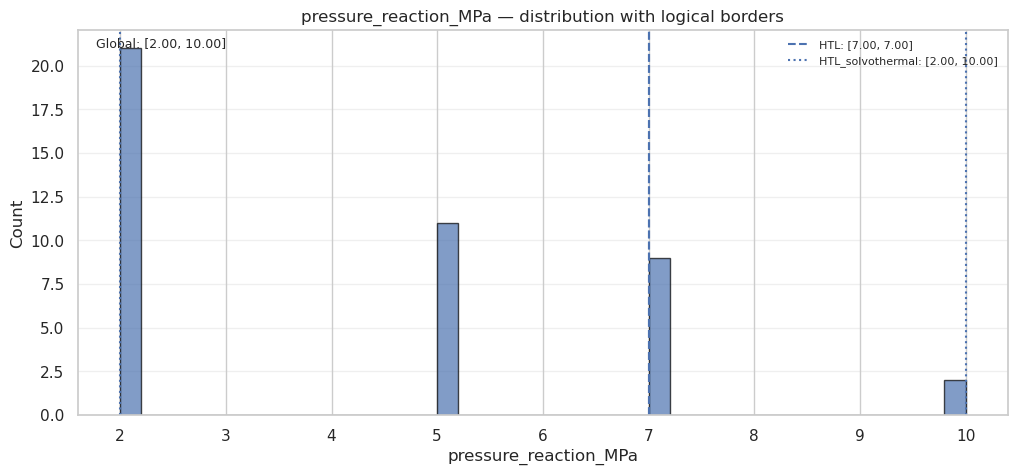

pressure_reaction_MPa: n=43 range=[2, 10]


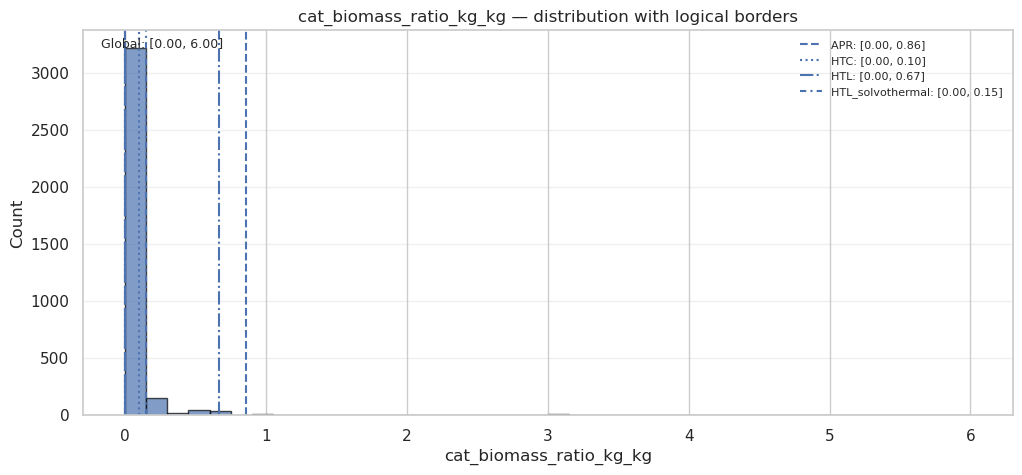

cat_biomass_ratio_kg_kg: n=3493 range=[0, 6]


In [18]:
import importlib
import feature_distributions
importlib.reload(feature_distributions)

from feature_distributions import run_feature_distribution_analysis

features = [
    'C_feed_wt_pct', 'H_feed_wt_pct', 'O_feed_wt_pct',
    'N_feed_wt_pct', 'S_feed_wt_pct', 'Ash_feed_wt_pct',
    'Lignin_feed_wt_pct', 'Cellulose_feed_wt_pct', 'Hemicellulose_feed_wt_pct',
    'T_reaction_C', 't_residence_min', 'IC_feed_wt_pct_slurry',
    'pressure_reaction_MPa', 'cat_biomass_ratio_kg_kg'
]

run_feature_distribution_analysis(
    df=df,
    features=features,
    process_col='process_subtype',
    show_combined=False,
    show_individual=False,
    show_serial=True
)

### Filter example: HTL above 300°C

In [41]:
htl_high_temp = df[
    (df['process_subtype'].str.contains('HTL', na=False)) & 
    (df['T_reaction_C'] >= 300)
]

print(f"HTL experiments ≥300°C: {len(htl_high_temp):,} runs")
print(f"Mean bio-oil yield: {htl_high_temp['Yield_biooil_wt_pct'].mean():.1f}%")
print(f"Median temperature: {htl_high_temp['T_reaction_C'].median():.0f}°C")

HTL experiments ≥300°C: 1,825 runs
Mean bio-oil yield: 30.2%
Median temperature: 320°C


### Numeric feature distributions

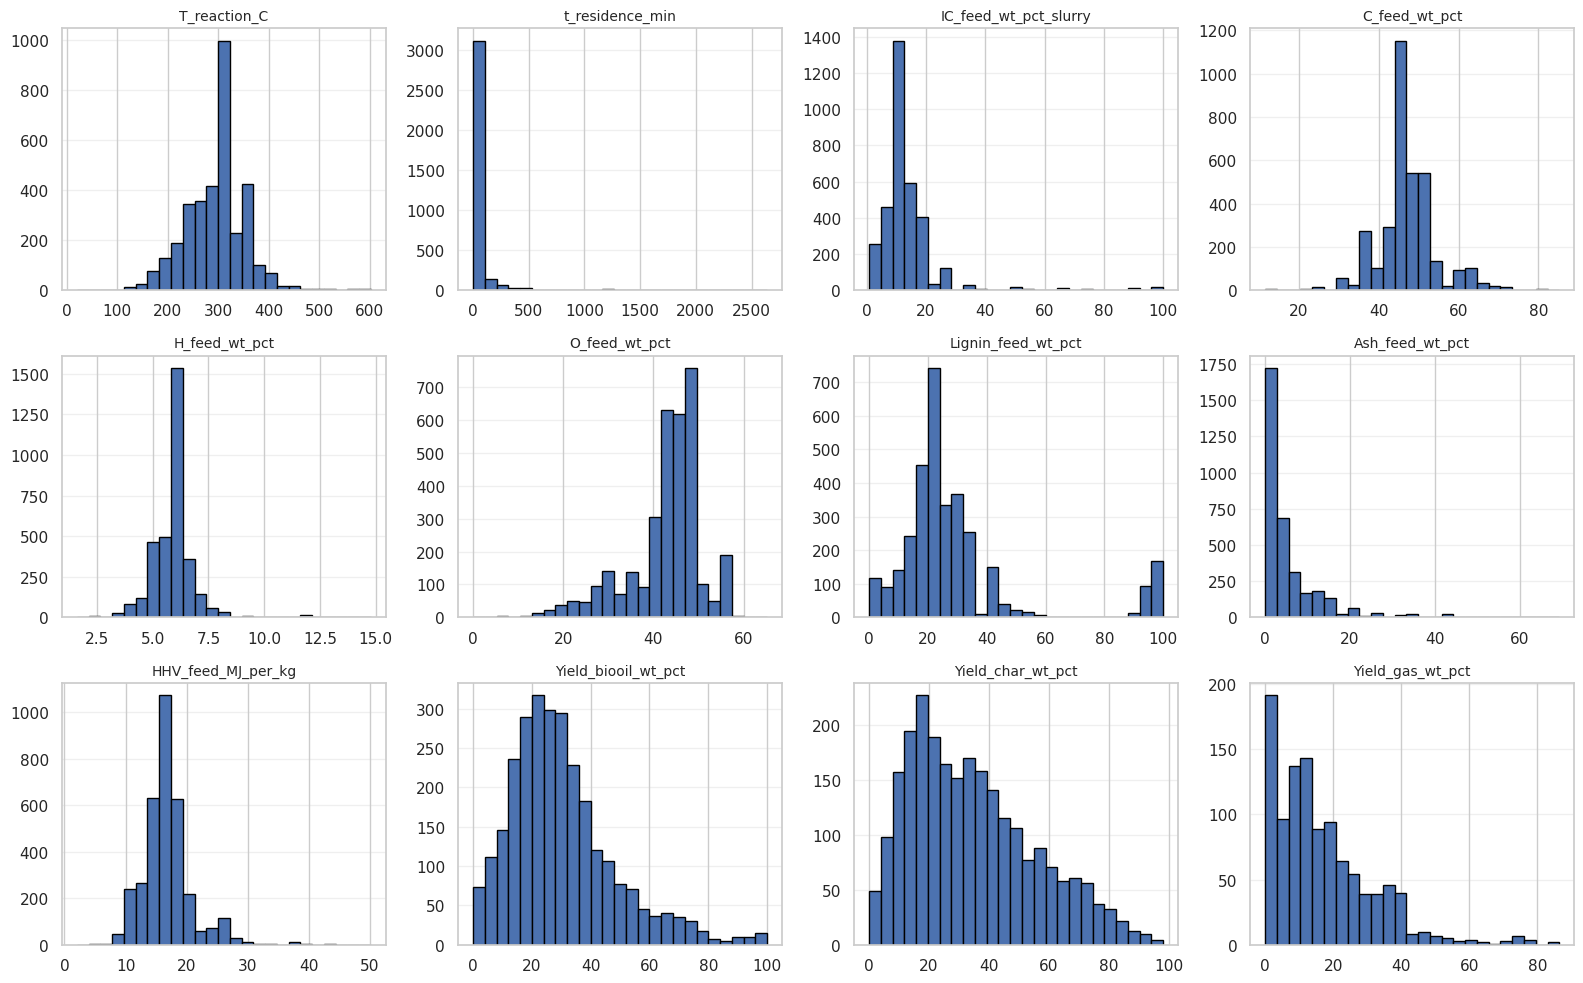

In [42]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
key_features = [
    'T_reaction_C', 't_residence_min', 'IC_feed_wt_pct_slurry',
    'C_feed_wt_pct', 'H_feed_wt_pct', 'O_feed_wt_pct', 
    'Lignin_feed_wt_pct', 'Ash_feed_wt_pct', 'HHV_feed_MJ_per_kg',
    'Yield_biooil_wt_pct', 'Yield_char_wt_pct', 'Yield_gas_wt_pct'
]

available_features = [col for col in key_features if col in df.columns]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(available_features[:12]):
    df[col].hist(bins=25, ax=axes[idx], edgecolor='black')
    axes[idx].set_title(col, fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

for idx in range(len(available_features), 12):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()